# 02 — Advanced Telecom RAG demo and evaluation

This notebook builds the upgraded retrieval pipeline and measures each stage separately.

The original baseline was:

```text
question → MiniLM → FAISS top-4 → LLM
```

The upgraded system is:

```text
                         question
                            ↓
                    clean retrieval query
                            ↓
                 ┌──────────┴──────────┐
                 ↓                     ↓
          BGE dense retrieval       BM25 lexical
              top 15                  top 15
                 └──────────┬──────────┘
                            ↓
                  reciprocal-rank fusion
                            ↓
                    ~20 candidates
                            ↓
                  cross-encoder reranker
                            ↓
                       best 4 chunks
                            ↓
                  + full KPI context
                            ↓
                           LLM
```

We evaluate **dense vs hybrid vs reranked retrieval** before evaluating generation. This makes it possible to see where improvements actually come from.

## 0. Environment

The repository targets **Python 3.12**. Install the locked environment and start Jupyter from the repository root:

```bash
uv sync
uv run jupyter lab
```

The first local retrieval run downloads:
- `BAAI/bge-small-en-v1.5` for dense embeddings,
- `cross-encoder/ms-marco-MiniLM-L6-v2` for local reranking.

These retrieval models run locally and are separate from the generator.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

Project root: /home/fredriknguyen/Documents/Telecom-RAG


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from telecom_rag.config import (
    EMBEDDING_MODEL, RERANKER_MODEL, CHUNK_SIZE, CHUNK_OVERLAP,
    VECTOR_STORE_DIR, PROCESSED_KPI_PATH,
)

print("Embedding model:", EMBEDDING_MODEL)
print("Reranker:", RERANKER_MODEL)
print("Chunk size / overlap:", CHUNK_SIZE, "/", CHUNK_OVERLAP)

Embedding model: BAAI/bge-small-en-v1.5
Reranker: cross-encoder/ms-marco-MiniLM-L6-v2
Chunk size / overlap: 1700 / 250


## 1. Download the expanded corpus

The corpus now contains **10 configured sources**, not just four. It combines:
- NR and LTE measurement standards,
- NR data procedures and overall architecture,
- the exact AERPAW/Ericsson experiment documentation,
- applied Ericsson material about beamforming, coverage/capacity, optimization and real-world 5G performance.

A larger corpus makes retrieval harder, which is useful: BM25/reranking now have a meaningful job rather than choosing among only a few documents.

In [3]:
import subprocess

subprocess.run(
    [sys.executable, str(ROOT / "scripts" / "download_docs.py")],
    check=False,
)

Downloading: 3GPP TS 38.215 Release 18: NR physical layer measurements.
  saved /home/fredriknguyen/Documents/Telecom-RAG/docs/corpus/etsi_ts_138215_v18_5_0.pdf
Downloading: 3GPP TS 38.214 Release 18: NR physical layer procedures for data.
  saved /home/fredriknguyen/Documents/Telecom-RAG/docs/corpus/etsi_ts_138214_v18_10_0.pdf
Downloading: 3GPP TS 38.300 Release 18: NR and NG-RAN overall description.
  saved /home/fredriknguyen/Documents/Telecom-RAG/docs/corpus/etsi_ts_138300_v18_5_0.pdf
Downloading: 3GPP TS 36.214 Release 18: LTE physical layer measurements.
  saved /home/fredriknguyen/Documents/Telecom-RAG/docs/corpus/etsi_ts_136214_v18_0_0.pdf
Downloading: AERPAW dataset description for the Ericsson 5G NSA UAV experiment.
  saved /home/fredriknguyen/Documents/Telecom-RAG/docs/corpus/aerpaw_ericsson_dataset.txt
Downloading: AERPAW user manual: Ericsson experiment log post-processing.
  saved /home/fredriknguyen/Documents/Telecom-RAG/docs/corpus/aerpaw_post_processing.txt
Downloading

CompletedProcess(args=['/home/fredriknguyen/Documents/Telecom-RAG/.venv/bin/python3', '/home/fredriknguyen/Documents/Telecom-RAG/scripts/download_docs.py'], returncode=0)

In [4]:
from telecom_rag.config import DOCS_DIR

source_files = [
    p for p in sorted(DOCS_DIR.glob("*"))
    if p.is_file() and not p.name.startswith("_") and not p.name.startswith(".")
]
print("Downloaded source files:", len(source_files))
for p in source_files:
    print(f"{p.name:48s} {p.stat().st_size / 1024:9.1f} KB")

Downloaded source files: 9
aerpaw_ericsson_dataset.txt                            7.1 KB
aerpaw_post_processing.txt                             3.2 KB
ericsson_ai_network_performance.txt                   11.3 KB
ericsson_mobility_report_june_2025.pdf              6870.8 KB
ericsson_traffic_patterns.txt                         10.3 KB
etsi_ts_136214_v18_0_0.pdf                           186.5 KB
etsi_ts_138214_v18_10_0.pdf                         4257.3 KB
etsi_ts_138215_v18_5_0.pdf                           266.3 KB
etsi_ts_138300_v18_5_0.pdf                          3069.0 KB


## 2. Load documents with source metadata

PDFs are loaded page-by-page. For technical PDFs we also attempt to detect a numbered section heading. The metadata later becomes both retrieval context and visible citations.

In [5]:
from telecom_rag.documents import load_documents

docs = load_documents()
print("Document/page objects:", len(docs))
print(docs[0].metadata)
print(docs[0].page_content[:600])

/home/fredriknguyen/Documents/Telecom-RAG/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Document/page objects: 687
{'source_id': 'aerpaw_ericsson_dataset', 'source': 'aerpaw_ericsson_dataset.txt', 'title': 'AERPAW dataset description for the Ericsson 5G NSA UAV experiment.', 'page': None, 'section': None, 'path': '/home/fredriknguyen/Documents/Telecom-RAG/docs/corpus/aerpaw_ericsson_dataset.txt'}
Title: AERPAW dataset description for the Ericsson 5G NSA UAV experiment.
Source URL: https://aerpaw.org/dataset/aerpaw-ericsson-5g-uav-experiment/

LnRiLWZpZWxke21hcmdpbi1ib3R0b206MC43NmVtfS50Yi1maWVsZC0tbGVmdHt0ZXh0LWFsaWduOmxlZnR9LnRiLWZpZWxkLS1jZW50ZXJ7dGV4dC1hbGlnbjpjZW50ZXJ9LnRiLWZpZWxkLS1yaWdodHt0ZXh0LWFsaWduOnJpZ2h0fS50Yi1maWVsZF9fc2t5cGVfcHJldmlld3twYWRkaW5nOjEwcHggMjBweDtib3JkZXItcmFkaXVzOjNweDtjb2xvcjojZmZmO2JhY2tncm91bmQ6IzAwYWZlZTtkaXNwbGF5OmlubGluZS1ibG9ja311bC5nbGlkZV9fc2xpZGVze21hcmdpbjowfQ==
LnRiLWhlYWRpbmcuaGFzLWJhY2tncm91bmR7cGFkZGluZzowfQ==
ICAgLnRiLWZpZWxkW2RhdGEtdG9vbHNld


## 3. Section-aware contextual chunking

The old baseline split raw text into fixed fragments.

The upgraded chunker:
1. respects paragraphs/newlines before splitting inside sentences,
2. uses larger ~400-token chunks,
3. keeps overlap,
4. prepends document title + section + page to every chunk.

That header is part of the embedding input, so similar definitions from different standards are easier to disambiguate.

In [6]:
from telecom_rag.documents import chunk_documents

chunks = chunk_documents(docs)
print("Chunks:", len(chunks))
print(chunks[0].metadata)
print(chunks[0].page_content[:800])

Chunks: 1995
{'source_id': 'aerpaw_ericsson_dataset', 'source': 'aerpaw_ericsson_dataset.txt', 'title': 'AERPAW dataset description for the Ericsson 5G NSA UAV experiment.', 'page': None, 'section': None, 'path': '/home/fredriknguyen/Documents/Telecom-RAG/docs/corpus/aerpaw_ericsson_dataset.txt', 'chunk_id': 'chunk_00000'}
Document: AERPAW dataset description for the Ericsson 5G NSA UAV experiment.

Title: AERPAW dataset description for the Ericsson 5G NSA UAV experiment.
Source URL: https://aerpaw.org/dataset/aerpaw-ericsson-5g-uav-experiment/


## 4. Build the BGE/FAISS index

We switched from a generic MiniLM sentence embedding model to the retrieval-oriented `BAAI/bge-small-en-v1.5`.

The index is versioned with a manifest containing:
- embedding model,
- chunk size,
- overlap,
- chunking version.

This matters because BGE-small and the old MiniLM model are both 384-dimensional. Without a manifest, an old FAISS index could silently be reused with the wrong embedding model.

In [7]:
from telecom_rag.rag import build_vector_store, index_is_current

store = build_vector_store()
print("Vectors:", store.index.ntotal)
print("Index current:", index_is_current())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18470.98it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   2%|▏         | 1/63 [00:02<02:44,  2.65s/it]

Batches:   3%|▎         | 2/63 [00:05<02:41,  2.65s/it]

...

Batches:  97%|█████████▋| 61/63 [02:37<00:02,  1.16s/it]

Batches:  98%|█████████▊| 62/63 [02:38<00:01,  1.03s/it]

Batches: 100%|██████████| 63/63 [02:38<00:00,  1.32it/s]

Batches: 100%|██████████| 63/63 [02:38<00:00,  2.51s/it]

Vectors: 1995
Index current: True


## 5. Load the full advanced retriever

The retriever owns:
- FAISS/BGE dense search,
- BM25 lexical search,
- reciprocal-rank fusion (RRF),
- a cross-encoder reranker.

The cross-encoder is loaded lazily only when the `reranked` mode is first used.

In [8]:
from telecom_rag.rag import load_advanced_retriever

retriever = load_advanced_retriever(build_if_missing=False)
retriever

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19538.99it/s]

## 6. Why hybrid retrieval?

Dense search is strong for **meaning**:

> "radio quality under interference"

BM25 is strong for exact telecom/file tokens:

> `NR5G_RSRP`, `Serving_cell_Params_ENDC.csv`, `TS 38.215`

RRF combines the rankings without requiring their raw scores to be on the same scale.

In [9]:
query = "Which file contains serving-cell RF measurements in the AERPAW workflow?"

for mode in ["dense", "hybrid", "reranked"]:
    result = retriever.retrieve(query, k=4, mode=mode)
    print("\n", "=" * 25, mode.upper(), "=" * 25)
    for i, doc in enumerate(result.documents, 1):
        print(
            i,
            doc.metadata.get("source_id"),
            "page=", doc.metadata.get("page"),
            "methods=", doc.metadata.get("retrieval_methods"),
            "rerank=", doc.metadata.get("rerank_score"),
        )


 ========================= DENSE =========================
1 aerpaw_post_processing page= None methods= None rerank= None
2 etsi_ts_138214_v18_10_0 page= 174 methods= None rerank= None
3 aerpaw_ericsson_dataset page= None methods= None rerank= None
4 aerpaw_ericsson_dataset page= None methods= None rerank= None

 ========================= HYBRID =========================
1 aerpaw_post_processing page= None methods= dense+bm25 rerank= None
2 aerpaw_ericsson_dataset page= None methods= dense+bm25 rerank= None
3 aerpaw_post_processing page= None methods= dense+bm25 rerank= None
4 aerpaw_ericsson_dataset page= None methods= dense+bm25 rerank= None


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 17178.37it/s]


 ========================= RERANKED =========================
1 aerpaw_post_processing page= None methods= dense+bm25 rerank= 3.7948548793792725
2 aerpaw_post_processing page= None methods= dense+bm25 rerank= 3.358835458755493
3 aerpaw_ericsson_dataset page= None methods= dense+bm25 rerank= 0.8962461352348328
4 aerpaw_ericsson_dataset page= None methods= dense+bm25 rerank= -0.9975029230117798


## 7. Cleaner KPI-conditioned retrieval queries

The previous graph appended the *entire* KPI summary—numbers, percentiles, anomaly scores and timestamps—to the embedding query.

That can dilute retrieval.

The upgraded graph keeps:
- the user's question,
- only useful KPI **names/concepts** for search.

Detailed numeric KPI context is added later, at generation time.

In [10]:
from telecom_rag.retrieval import build_retrieval_query

example_observation = {
    "nr_rsrp_dbm": -96,
    "nr_sinr_db": 4,
    "nr_cqi": 5,
    "nr_mcs": 7,
    "throughput_mbps": 12,
}
q = "Why might this observation have poor throughput?"
print(build_retrieval_query(q, example_observation))

Why might this observation have poor throughput? Telecom radio measurements: throughput rsrp sinr cqi mcs


## 8. Inspect reranked evidence

This is the evidence the LLM will actually see. Always inspect retrieval before changing prompts or models.

In [11]:
final = retriever.retrieve(
    "Why might reasonable SSB RSRP fail to predict NR downlink throughput?",
    k=4,
    mode="reranked",
)
for i, doc in enumerate(final.documents, 1):
    print(f"\n--- S{i} ---")
    print(doc.metadata)
    print(doc.page_content[:900])


--- S1 ---
{'source_id': 'etsi_ts_138214_v18_10_0', 'source': 'etsi_ts_138214_v18_10_0.pdf', 'title': 'TS 138 214 - V18.10.0 - 5G; NR; Physical layer procedures for data  (3GPP TS 38.214 version 18.10.0 Release 18)', 'page': 11, 'section': None, 'path': '/home/fredriknguyen/Documents/Telecom-RAG/docs/corpus/etsi_ts_138214_v18_10_0.pdf', 'chunk_id': 'chunk_00227', 'dense_rank': 7, 'rrf_rank': 13, 'rrf_score': 0.014925373134328358, 'retrieval_methods': 'dense', 'rerank_rank': 1, 'rerank_score': 0.24081194400787354}
Document: TS 138 214 - V18.10.0 - 5G; NR; Physical layer procedures for data  (3GPP TS 38.214 version 18.10.0 Release 18)
Page: 11

ETSI
ETSI TS 138 214 V18.10.0 (2026-07)
10
3GPP TS 38.214 version 18.10.0 Release 18
PT-RS
Phase-Tracking Reference Signal
RB
Resource Block
RBG
Resource Block Group
RI
Rank Indicator
RIV
Resource Indicator Value
RS
Reference Signal
SCI
Sidelink Control Information
SL PRS
Sidelink Positioning Reference Signal
SLIV
Start and Length Indicator Value

## 9. Choose an LLM

The evaluation should use the **same generator as the deployment** when possible.

To use Cloudflare Workers AI, set `CLOUDFLARE_ACCOUNT_ID` and `CLOUDFLARE_API_TOKEN` in the shell **before** starting Jupyter, then launch:

```bash
uv run jupyter lab
```

Optional model override:

```bash
export CLOUDFLARE_GENERATOR_MODEL="@cf/google/gemma-4-26b-a4b-it"
```

The next cell automatically selects Cloudflare when those credentials are present. Otherwise it falls back to local Ollama/Qwen3 4B.

Cloudflare here changes the **generator**. The retrieval ablation in this notebook intentionally remains the reproducible local FAISS + BM25 + local reranker pipeline.

In [12]:
import os

from telecom_rag.config import CLOUDFLARE_MODEL, OLLAMA_MODEL
from telecom_rag.rag import get_llm

if os.getenv("CLOUDFLARE_ACCOUNT_ID") and os.getenv("CLOUDFLARE_API_TOKEN"):
    PROVIDER = "cloudflare"
    MODEL = os.getenv("CLOUDFLARE_GENERATOR_MODEL", CLOUDFLARE_MODEL)
else:
    PROVIDER = "ollama"
    MODEL = os.getenv("OLLAMA_MODEL", OLLAMA_MODEL)

print("Evaluation provider:", PROVIDER)
print("Evaluation model:", MODEL)

llm = get_llm(provider=PROVIDER, model=MODEL, max_output_tokens=96)

Evaluation provider: ollama
Evaluation model: qwen2.5:3b


## 10. LangGraph with the final retrieval pipeline

The graph still has a small purposeful structure:

```text
route question
   ├─ docs-only ──────────────┐
   └─ KPI question            │
          ↓                   │
      analyze KPI             │
          └────────→ retrieve ←┘
                         ↓
                      generate
```

The retrieval node now runs the advanced retriever and stores the clean query for debugging.

In [13]:
from telecom_rag.graph import build_graph

graph = build_graph(
    llm,
    retriever,
    reference_df=None,
    top_k=4,
    retrieval_mode="reranked",
)

In [14]:
result = graph.invoke({
    "question": "Why can SSB RSRP be a weak predictor of NR downlink data performance?",
    "use_rag": True,
    "observation": None,
})

print("Route:", result["route"])
print("Retrieval query:", result["retrieval_query"])
print("Retrieval mode:", result["retrieval_mode"])
print("\nAnswer:\n", result["answer"])

Route: docs-only
Retrieval query: Why can SSB RSRP be a weak predictor of NR downlink data performance?
Retrieval mode: reranked

Answer:
 ## Answer
SSB RSRP cannot be a strong predictor of NR downlink data performance because the SSB (Synchronization Signal Block) is designed for measuring the received power of the SSS (Secondary Synchronization Signal) and PBCH (Physical Broadcast Channel) and not for directly measuring the data channel performance. The SSB RSRP is derived from the SSS and PBCH EPRE, which are not directly related to the data channel EPRE. The data


## 11. KPI-aware demo

The graph uses numeric KPI percentiles/anomaly context for **generation**, while retrieval stays clean.

In [15]:
from telecom_rag.data import load_processed_kpis

if PROCESSED_KPI_PATH.exists():
    kpis = load_processed_kpis()
    if "anomaly_score" in kpis.columns:
        selected = kpis.sort_values("anomaly_score", ascending=False).iloc[0]
    else:
        selected = kpis.iloc[0]
    print(selected)
else:
    kpis = None
    selected = None
    print("Run Notebook 01 first for KPI-aware examples.")

observation_id                                 obs_00767
timestamp                     2023-09-15 11:45:13.601347
orientation                                       yaw315
latitude                                       35.727364
longitude                                     -78.696166
altitude                                        10.05549
lte_cell_id                                          2.0
nr_cell_id                                           1.0
lte_rsrp_dbm                                       -54.0
nr_rsrp_dbm                                        -77.0
lte_sinr_db                                         24.0
nr_sinr_db                                          37.0
nr_cqi                                              10.0
nr_mcs                                              18.0
nr_ri                                                3.0
throughput_mbps                                    291.0
source_sampling_interval_s                           1.0
anomaly_score                  

In [16]:
if selected is not None:
    kpi_graph = build_graph(
        llm,
        retriever,
        reference_df=kpis,
        top_k=4,
        retrieval_mode="reranked",
    )
    kpi_result = kpi_graph.invoke({
        "question": (
            "Why might this observation have this throughput, and which radio "
            "measurements should I investigate?"
        ),
        "use_rag": True,
        "observation": selected.to_dict(),
    })
    print("Retrieval query:", kpi_result["retrieval_query"])
    print("\nDetailed KPI generation context:\n", kpi_result.get("kpi_context", ""))
    print("\nAnswer:\n", kpi_result["answer"])

Retrieval query: Why might this observation have this throughput, and which radio measurements should I investigate? Telecom radio measurements: throughput rsrp sinr cqi mcs rank indicator

Detailed KPI generation context:
 Selected network observation (measured data):
- observation_id: obs_00767
- timestamp: 2023-09-15 11:45:13.601347
- UAV orientation group: yaw315

Marginal dataset comparison:
- LTE RSRP: -54 dBm (about the 100th percentile)
- NR RSRP: -77 dBm (about the 100th percentile)
- LTE SINR: 24 dB (about the 100th percentile)
- NR SINR: 37 dB (about the 100th percentile)
- NR CQI: 10 (about the 57th percentile)
- NR MCS: 18 (about the 54th percentile)
- NR RI: 3 (about the 100th percentile)
- Downlink throughput: 291 Mbps (about the 13th percentile)

Reference-dataset relationships with throughput:
- NR CQI vs throughput: rank correlation rho=+0.22 across n=1570 observations.
- NR SINR vs throughput: rank correlation rho=+0.22 across n=1525 observations.
- NR RSRP vs throug

## 12. Improved evaluation set

The original benchmark was dominated by basic definitions that a pretrained LLM already knows.

The new benchmark has **20 questions** split across:
- `general_telecom`,
- `corpus_specific`,
- `standard_specific`,
- `applied_diagnostics`,
- `cross_source`.

This makes RAG earn its value on experiment-specific facts, exact files, applied network-performance explanations and multi-source retrieval.

In [17]:
from telecom_rag.evaluation import load_eval_questions

questions = load_eval_questions()
eval_df = pd.DataFrame(questions)
print(eval_df.groupby(["category", "difficulty"]).size())
eval_df[["id", "category", "difficulty", "question"]].head(20)

category             difficulty
applied_diagnostics  hard          4
                     medium        1
corpus_specific      hard          3
                     medium        4
cross_source         hard          2
general_telecom      easy          4
standard_specific    medium        2
dtype: int64


,id,category,difficulty,question
0,q01,general_telecom,easy,What is RSRP used to measure in an NR radio link?
1,q02,general_telecom,easy,What kind of quantity is SINR and why is it us...
2,q03,general_telecom,easy,What does CQI communicate to the network in NR?
3,q04,general_telecom,easy,What is the role of MCS in NR data transmission?
4,q05,corpus_specific,medium,What deployment type was used in the AERPAW Er...
5,q06,corpus_specific,medium,At what UAV altitude were the Ericsson 5G NSA ...
6,q07,corpus_specific,medium,Which radio and performance KPIs are highlight...
7,q08,corpus_specific,medium,What equipment was mounted on the UAV to colle...
8,q09,corpus_specific,hard,Which log files are used for RF and PHY post-p...
9,q10,corpus_specific,hard,Why is the vehicle telemetry log useful when p...


## 13. Retrieval ablation: dense vs hybrid vs reranked

This is the most important diagnostic experiment.

Metrics:
- **source_hit** — at least one expected source document was retrieved,
- **source_recall** — fraction of expected source documents retrieved,
- **source_precision** — fraction of returned chunks from expected source(s),
- **MRR** — how early the first expected source appeared,
- **evidence_term_recall** — whether the final top-k passages actually contain the benchmark's key evidence terms,
- **retrieval_latency_s** — measured retrieval/reranking latency.

The evidence metric matters because retrieving the right PDF but the wrong passage should not count as a complete success.

In [18]:
from telecom_rag.evaluation import evaluate_retrieval, summarize_retrieval

retrieval_results = evaluate_retrieval(
    retriever,
    questions,
    k=4,
    modes=("dense", "hybrid", "reranked"),
)
retrieval_summary = summarize_retrieval(retrieval_results)
retrieval_summary

,source_hit,source_recall,source_precision,mrr,evidence_term_recall,retrieval_latency_s
mode,,,,,,
reranked,0.90,0.875,0.788,0.829,0.775,1.141
dense,0.90,0.875,0.675,0.792,0.800,0.016
hybrid,0.85,0.850,0.650,0.817,0.800,0.021


In [19]:
retrieval_by_category = (
    retrieval_results
    .groupby(["category", "mode"])[
        ["source_hit", "source_recall", "mrr", "evidence_term_recall", "retrieval_latency_s"]
    ]
    .mean()
    .round(3)
)
retrieval_by_category

source_hit  source_recall    mrr  \
category            mode                                         
applied_diagnostics dense           0.60           0.60  0.600   
                    hybrid          0.60           0.60  0.600   
                    reranked        0.60           0.60  0.600   
corpus_specific     dense           1.00           1.00  1.000   
                    hybrid          1.00           1.00  1.000   
                    reranked        1.00           1.00  1.000   
cross_source        dense           1.00           0.75  1.000   
                    hybrid          1.00           1.00  1.000   
                    reranked        1.00           0.75  1.000   
general_telecom     dense           1.00           1.00  0.458   
                    hybrid          0.75           0.75  0.583   
                    reranked        1.00           1.00  0.646   
standard_specific   dense           1.00           1.00  1.000   
                    hybrid          1.00           1.00  1.000   
                    reranked        1.00           1.00  1.000   

                              evidence_term_recall  retrieval_latency_s  
category            mode                                                 
applied_diagnostics dense                    0.617                0.016  
                    hybrid                   0.667                0.022  
                    reranked                 0.667                1.161  
corpus_specific     dense                    0.786                0.015  
                    hybrid                   0.786                0.020  
                    reranked                 0.786                0.995  
cross_source        dense                    0.875                0.015  
                    hybrid                   1.000                0.021  
                    reranked                 0.750                0.976  
general_telecom     dense                    0.917                0.018  
                    hybrid                   0.792                0.022  
                    reranked                 0.792                1.381  
standard_specific   dense                    1.000                0.014  
                    hybrid                   1.000                0.019  
                    reranked                 1.000                1.284

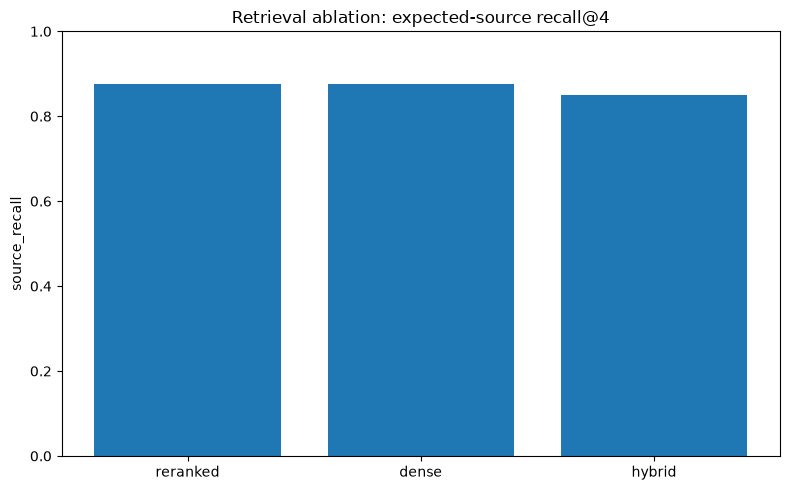

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
metric = "source_recall"
summary_for_plot = retrieval_summary[metric]
ax.bar(summary_for_plot.index, summary_for_plot.values)
ax.set_ylim(0, 1)
ax.set_ylabel(metric)
ax.set_title("Retrieval ablation: expected-source recall@4")
plt.tight_layout()
plt.show()

## 14. Inspect retrieval failures

This tells us whether remaining errors are:
- semantic retrieval failures,
- lexical retrieval failures,
- reranker failures,
- benchmark/source-label issues.

In [21]:
failed = retrieval_results[
    (retrieval_results["mode"] == "reranked") &
    (
        (retrieval_results["source_recall"] < 1) |
        (retrieval_results["evidence_term_recall"] < 1)
    )
]
failed[[
    "id", "category", "question",
    "expected_source_ids", "retrieved_source_ids",
    "source_recall", "evidence_term_recall", "mrr", "retrieval_latency_s"
]]

,id,category,question,expected_source_ids,retrieved_source_ids,source_recall,evidence_term_recall,mrr,retrieval_latency_s
8,q03,general_telecom,What does CQI communicate to the network in NR?,[etsi_ts_138214_v18_10_0],"[etsi_ts_138214_v18_10_0, etsi_ts_138214_v18_1...",1.0,0.666667,1.0,1.298280
11,q04,general_telecom,What is the role of MCS in NR data transmission?,[etsi_ts_138214_v18_10_0],"[etsi_ts_138214_v18_10_0, etsi_ts_138214_v18_1...",1.0,0.500000,1.0,1.466037
29,q10,corpus_specific,Why is the vehicle telemetry log useful when p...,[aerpaw_post_processing],"[aerpaw_post_processing, aerpaw_post_processin...",1.0,0.500000,1.0,0.975552
38,q13,applied_diagnostics,Why can SSB RSRP or SINR be a weak predictor o...,[ericsson_massive_mimo_beamforming],"[etsi_ts_138214_v18_10_0, etsi_ts_136214_v18_0...",0.0,0.333333,0.0,1.241435
50,q17,corpus_specific,Which two UAV yaw orientations are represented...,[aerpaw_ericsson_dataset],"[aerpaw_ericsson_dataset, aerpaw_ericsson_data...",1.0,0.000000,1.0,1.049620
56,q19,cross_source,Which standards in the corpus are most relevan...,"[etsi_ts_138215_v18_5_0, etsi_ts_138214_v18_10_0]","[etsi_ts_138214_v18_10_0, etsi_ts_138214_v18_1...",0.5,0.500000,1.0,0.974344
59,q20,applied_diagnostics,If an NR observation has reasonable SSB RSRP b...,[ericsson_massive_mimo_beamforming],"[etsi_ts_138215_v18_5_0, etsi_ts_138215_v18_5_...",0.0,0.000000,0.0,1.171370


## 15. Same LLM: baseline vs final RAG

Only now do we test generation.

The comparison uses the **same LLM and all 20 questions**. RAG uses the final reranked pipeline.

Generation metrics:
- **semantic_similarity** — similarity to the reference answer,
- **required_term_recall** — transparent required-fact keyword coverage,
- **citation_present** — whether RAG emitted citations,
- **citation_reference_validity** — whether cited [S#] references actually exist,
- **citation_support_similarity** — similarity between each cited claim and the chunk(s) it cites; a support proxy, not entailment,
- **answer_context_similarity** — whole-answer similarity to retrieved evidence; a coarse grounding proxy,
- **evidence_term_recall** — whether retrieved passages contained the benchmark's key evidence,
- **generation_latency_s**, **retrieval_latency_s**, and **total_latency_s**.

None of the embedding-similarity metrics is a factuality/entailment score. Interpret them together with retrieval metrics and manual answer inspection.

In [22]:
from telecom_rag.rag import get_embeddings
from telecom_rag.evaluation import compare_baseline_and_rag, summarize_comparison

embeddings = get_embeddings()

results = compare_baseline_and_rag(
    llm=llm,
    retriever=retriever,
    embeddings=embeddings,
    questions=questions,
    k=4,
    retrieval_mode="reranked",
    limit=5,  # bounded local execution; the source benchmark defines all 20
)

comparison_summary = summarize_comparison(results)
comparison_summary

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17438.66it/s]

,semantic_similarity,required_term_recall,citation_present,citation_reference_validity,citation_support_similarity,answer_context_similarity,evidence_term_recall,generation_latency_s,retrieval_latency_s,total_latency_s
mode,,,,,,,,,,
llm_only,0.789,0.733,0.0,NaN,NaN,NaN,NaN,4.001,0.000,4.001
rag,0.800,1.000,0.0,0.0,0.0,0.84,0.833,4.169,1.171,5.340


## 16. The important view: results by category

A basic telecom definition is where the LLM-only baseline is strongest.

The RAG system should show its clearest advantage on:
- corpus-specific,
- standard-specific,
- applied-diagnostic,
- cross-source questions.

In [23]:
category_summary = summarize_comparison(results, by_category=True)
category_summary

semantic_similarity  required_term_recall  \
category        mode                                                  
corpus_specific llm_only                0.600                 0.000   
                rag                     0.734                 1.000   
general_telecom llm_only                0.836                 0.917   
                rag                     0.816                 1.000   

                          citation_present  citation_reference_validity  \
category        mode                                                      
corpus_specific llm_only               0.0                          NaN   
                rag                    0.0                          0.0   
general_telecom llm_only               0.0                          NaN   
                rag                    0.0                          0.0   

                          citation_support_similarity  \
category        mode                                    
corpus_specific llm_only                          NaN   
                rag                               0.0   
general_telecom llm_only                          NaN   
                rag                               0.0   

                          answer_context_similarity  evidence_term_recall  \
category        mode                                                        
corpus_specific llm_only                        NaN                   NaN   
                rag                           0.893                 1.000   
general_telecom llm_only                        NaN                   NaN   
                rag                           0.827                 0.792   

                          generation_latency_s  retrieval_latency_s  \
category        mode                                                  
corpus_specific llm_only                 2.358                0.000   
                rag                      3.993                1.557   
general_telecom llm_only                 4.411                0.000   
                rag                      4.213                1.074   

                          total_latency_s  
category        mode                       
corpus_specific llm_only            2.358  
                rag                 5.550  
general_telecom llm_only            4.411  
                rag                 5.288

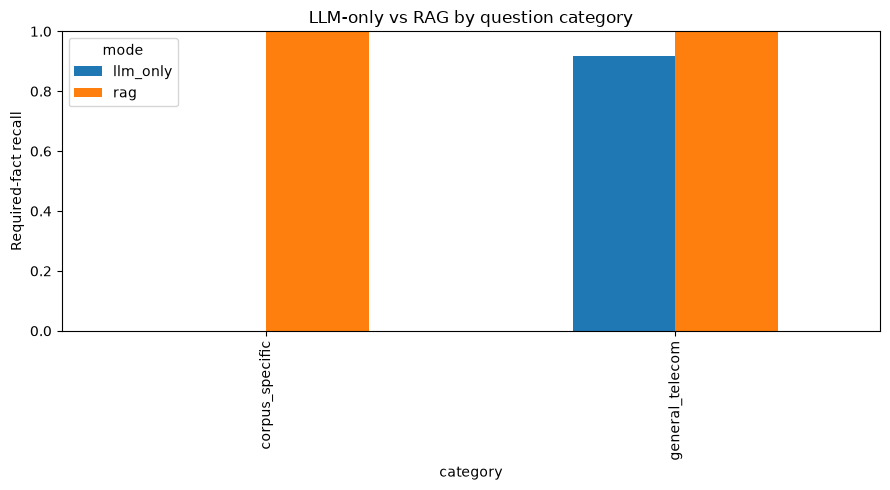

In [24]:
pivot = (
    results.groupby(["category", "mode"])["required_term_recall"]
    .mean()
    .unstack("mode")
)
pivot.plot(kind="bar", figsize=(9, 5))
plt.ylim(0, 1)
plt.ylabel("Required-fact recall")
plt.title("LLM-only vs RAG by question category")
plt.tight_layout()
plt.show()

## 17. Inspect answer-level failures

Averages can hide the useful story. For each bad case ask:

1. Was the expected source retrieved?
2. Did the reranker place it in the final top-4?
3. Did the answer use/cite the evidence?
4. Did the benchmark require wording that is too brittle?
5. Did RAG correctly say the evidence was insufficient?

In [25]:
for qid in results["id"].unique():
    pair = results[results["id"] == qid]
    print("\n" + "=" * 90)
    print(qid, pair.iloc[0]["category"], "-", pair.iloc[0]["question"])
    for _, row in pair.iterrows():
        extras = ""
        if row["mode"] == "rag":
            extras = (
                f" evidence={row['evidence_term_recall']:.2f}"
                f" cite_ref={row['citation_reference_validity']:.2f}"
                f" cite_support={row['citation_support_similarity']:.2f}"
            )
        print(
            f"\n[{row['mode']}] term_recall={row['required_term_recall']:.2f} "
            f"semantic={row['semantic_similarity']:.2f}"
            f" total_latency={row['total_latency_s']:.2f}s"
            + extras
        )
        print(row["answer"][:1000])


q01 general_telecom - What is RSRP used to measure in an NR radio link?

[llm_only] term_recall=1.00 semantic=0.94 total_latency=11.23s
RSRP, or Reference Signal Received Power, is used to measure the strength of the reference signals received on a cell site in an NR (New Radio) radio link. Specifically, it quantifies the signal strength of the cell's reference signals, which are used for various aspects of communication, including channel estimation, power control, and link budget calculations. RSRP is typically expressed in decibel-milliwatts (dBm) and is averaged over a certain cell area,

[rag] term_recall=1.00 semantic=0.94 total_latency=4.98s evidence=1.00 cite_ref=0.00 cite_support=0.00
## Answer
RSRP (Reference Signal Received Power) is used to measure the received power of the reference signals, specifically the demodulation reference signals for the Physical Broadcast Channel (PBCH) in an NR (New Radio) radio link. This measurement is taken into account for linear averaging 

## 18. Persist results and decide what to tune next

The notebook now evaluates all 20 questions by default. Save the raw tables so results can be inspected later without relying on notebook output state.

Interpret the ablations:
- low dense recall → embedding/query/chunk problem,
- hybrid beats dense → exact terminology matters,
- reranker beats hybrid → candidate retrieval is good but ordering was weak,
- source recall is high but evidence-term recall is low → right document, wrong passage,
- retrieval/evidence metrics are strong but answer metrics are weak → prompt/generator issue,
- generic questions show little gain but corpus-specific/cross-source questions improve → expected RAG behavior.

Useful next controlled experiments:
- chunk size: 1200 / 1700 / 2200 characters,
- candidate counts: 10 / 20 / 30,
- final top-k: 3 / 4 / 6,
- BGE small vs base,
- reranker on/off,
- corpus subsets (standards only vs standards + applied Ericsson material).

In [26]:
from telecom_rag.config import PROJECT_ROOT

results_dir = PROJECT_ROOT / "eval" / "results"
results_dir.mkdir(parents=True, exist_ok=True)

retrieval_results.to_csv(results_dir / "retrieval_ablation.csv", index=False)
results.to_csv(results_dir / "generation_comparison.csv", index=False)
retrieval_summary.to_csv(results_dir / "retrieval_summary.csv")
comparison_summary.to_csv(results_dir / "generation_summary.csv")
category_summary.to_csv(results_dir / "generation_by_category.csv")

print(f"Saved evaluation outputs to {results_dir}")

Saved evaluation outputs to /home/fredriknguyen/Documents/Telecom-RAG/eval/results
